<a href="https://colab.research.google.com/github/rijal0708/data-science-2026/blob/main/Pertemuan7_M_Rijal_Anshory_DJ_240401010281.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama    = M Rijal Anshory DJ
NIM     = 240401010281
Kelas   = IF403

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


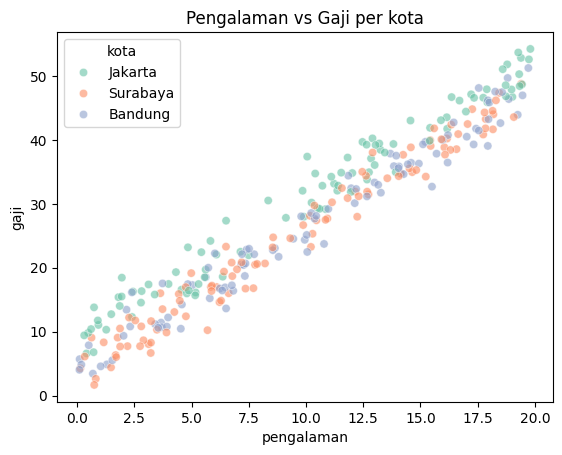

In [ ]:
# 1 GENERATE & EKSPLORASI DATASET

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#generate dataset sintesis
np.random.seed(42); n = 300
pengalaman  = np.random.uniform(0, 20, n)
edu         = np.random.choice([0, 1, 2], n)
kota        = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)
gaji        = (3.0 + 2.2*pengalaman +1.5*edu
               + np.where(kota=='Jakarta', 4.0, 0)
               + np.random.normal(0, 2, n))

df = pd.DataFrame({'pengalaman':pengalaman, 'edu':edu, 'kota':kota, 'gaji':gaji})

#EDA singkat
print('Shape:', df.shape)
print(df.describe().round(2))

#scatter pengalaman vs gaji
sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per kota')
plt.show()

In [ ]:
# 2 PREPROCESSING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

x = df.drop('gaji', axis=1)
y = df['gaji']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


In [ ]:
# 3 LATIH MODEL & TAMPILKAN KOEFISIEN

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_s, y_train)

print(f'β0 (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
    'Fitur' : x.columns,
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))


β0 (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292




---


Fitur yang paling berpengaruh Jika dilihat dari nilai absolut koefisien:


1.   pengalaman (13.042) → pengaruh paling besar

2.   kota_Jakarta (1.837)


3.   edu (1.188)
4.   kota_Surabaya (-0.292) → pengaruh paling kecil






Kesimpulan

Pengalaman kerja merupakan faktor yang paling memengaruhi gaji, karena memiliki koefisien terbesar (13.042). Artinya, semakin banyak pengalaman yang dimiliki seseorang, semakin tinggi gaji yang diprediksi oleh model. Sementara itu, bekerja di Jakarta juga cenderung meningkatkan gaji, pendidikan memberikan pengaruh positif namun lebih kecil, dan bekerja di Surabaya sedikit menurunkan gaji dibanding kota referensi yang digunakan dalam model.


---




In [7]:
# 4 EVALUASI MODEL
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse  = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('==== Metrik Evaluasi ====')
print(f'MAE   = {mae:.3f} juta rupiah')
print(f'RMSE  = {rmse:.3f} juta rupiah')
print(f'R2    = {r2:.4f} ({r2*100:1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

#

==== Metrik Evaluasi ====
MAE   = 1.649 juta rupiah
RMSE  = 2.123 juta rupiah
R2    = 0.9740 (97.395904% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


## Interpretasi Hasil Evaluasi Model

### 1. Berapa rata-rata kesalahan prediksi dalam rupiah?
Nilai MAE (Mean Absolute Error) sebesar **1,649 juta rupiah** menunjukkan bahwa rata-rata selisih antara gaji hasil prediksi dan gaji sebenarnya adalah sekitar **Rp1.649.000**. Dengan kata lain, model biasanya melakukan kesalahan prediksi sekitar 1,65 juta rupiah.

### 2. Apakah R² cukup baik untuk kasus ini?
Ya. Nilai **R² = 0,974** menunjukkan bahwa model mampu menjelaskan sekitar **97,4% variasi gaji** berdasarkan variabel pengalaman kerja, pendidikan, dan kota. Nilai ini sangat tinggi, sehingga dapat disimpulkan bahwa model memiliki kemampuan prediksi yang sangat baik untuk kasus ini.

### 3. Apakah ada indikasi outlier?
Indikasi outlier dapat dilihat dari perbedaan antara MAE dan RMSE. Nilai **RMSE = 2,123 juta rupiah** hanya sedikit lebih besar daripada **MAE = 1,649 juta rupiah**, dengan selisih sekitar **0,474 juta rupiah**. Hal ini menunjukkan bahwa tidak terdapat banyak kesalahan prediksi yang sangat besar (outlier), sehingga distribusi error model relatif stabil dan tidak terlalu dipengaruhi oleh data ekstrem.

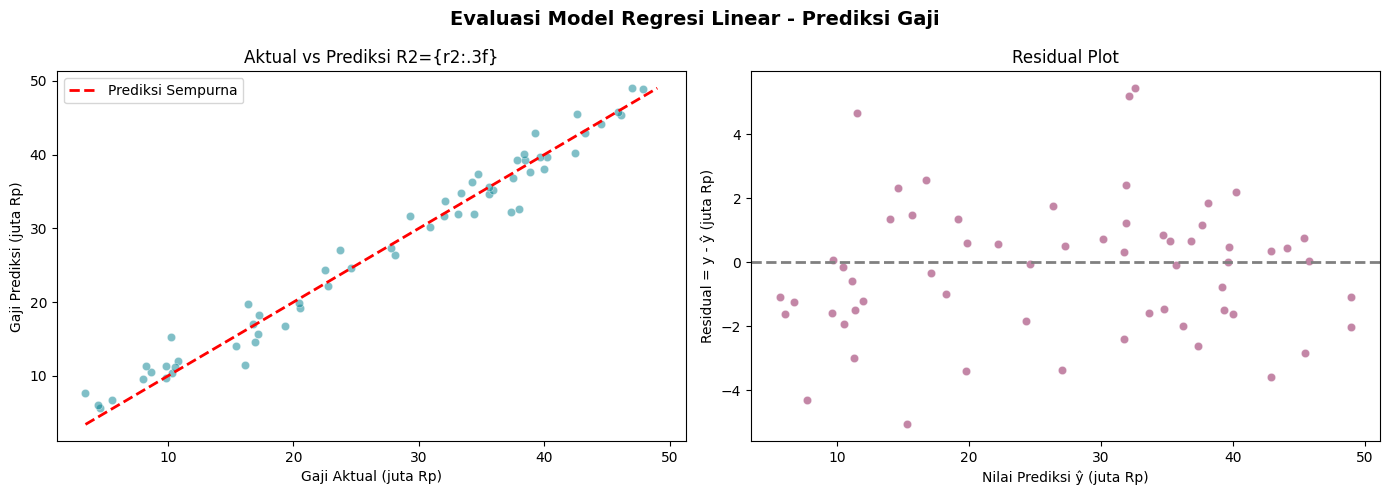

In [9]:
# 5 VISUALISASI & INTERPRESTASI

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#plot1 : aktual vs prediksi
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title('Aktual vs Prediksi R2={r2:.3f}')
axes[0].legend()

#plot2 : residual
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y - ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear - Prediksi Gaji', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

#

# Interpretasi Evaluasi Model Regresi Linear

## 1. Plot Aktual vs Prediksi

### What?
Plot ini membandingkan **gaji aktual** dengan **gaji hasil prediksi model**. Garis merah putus-putus menunjukkan prediksi sempurna (nilai aktual = nilai prediksi). Sebagian besar titik berada sangat dekat dengan garis tersebut, menunjukkan bahwa hasil prediksi model mendekati nilai sebenarnya. Nilai **R² = 0,974** juga menunjukkan tingkat kecocokan yang sangat tinggi.

### So What?
Kedekatan titik-titik terhadap garis prediksi sempurna mengindikasikan bahwa model regresi linear mampu menangkap hubungan antara variabel pengalaman, pendidikan, dan kota dengan gaji secara akurat. Hal ini didukung oleh nilai R² yang tinggi, yang berarti sekitar **97,4% variasi gaji dapat dijelaskan oleh model**.

### Now What?
Model dapat digunakan untuk melakukan prediksi gaji dengan tingkat kepercayaan yang cukup tinggi. Namun, sebelum digunakan pada data nyata yang lebih luas, perlu dilakukan validasi tambahan menggunakan dataset lain atau teknik *cross-validation* untuk memastikan model tidak mengalami *overfitting*.

---

## 2. Residual Plot

### What?
Residual plot menampilkan selisih antara nilai aktual dan nilai prediksi (**residual = y − ŷ**) terhadap nilai prediksi. Titik-titik residual terlihat menyebar di sekitar garis nol tanpa pola tertentu yang jelas. Sebagian besar residual berada dalam rentang sekitar ±3 juta rupiah, meskipun terdapat beberapa titik dengan residual mendekati ±5 juta rupiah.

### So What?
Penyebaran residual yang acak di sekitar nol menunjukkan bahwa asumsi linearitas model cukup terpenuhi dan model tidak menunjukkan bias sistematis (tidak selalu *overestimate* atau *underestimate*). Selain itu, tidak terlihat pola berbentuk kurva atau corong (*funnel shape*) yang kuat, sehingga indikasi heteroskedastisitas relatif kecil. Beberapa residual yang cukup besar dapat dianggap sebagai kandidat *outlier*, tetapi jumlahnya tidak banyak.

### Now What?
Model sudah menunjukkan performa yang baik dan asumsi dasar regresi linear relatif terpenuhi. Untuk analisis lebih lanjut, dapat dilakukan pemeriksaan *outlier* menggunakan metode seperti Z-Score, IQR, atau Cook's Distance. Jika ditemukan *outlier* yang signifikan, dapat dianalisis apakah data tersebut merupakan kesalahan pencatatan atau memang observasi yang valid.

---

# Kesimpulan Umum

### What?
Model menghasilkan prediksi yang sangat dekat dengan nilai aktual dan residual tersebar acak di sekitar nol.

### So What?
Model memiliki akurasi tinggi (**R² = 97,4%**) serta tidak menunjukkan pelanggaran asumsi regresi yang serius.

### Now What?
Model layak digunakan untuk prediksi gaji dan dapat ditingkatkan lebih lanjut melalui validasi tambahan serta analisis *outlier* untuk memastikan kestabilan performa pada data baru.